---

Reconecte ao Drive.

In [1]:
import os
DRIVE_DIRECTORY = "curso_ml"
DRIVE_DIRECTORY = os.path.join("/content/drive/MyDrive", DRIVE_DIRECTORY)

---

In [2]:
import pickle

import numpy as np

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from yellowbrick.classifier import ConfusionMatrix

# Support Vector Machine - SVM

Comece recuperando os dados preditores, de treino e de teste, a partir do arquivo `cover_type.pkl` salvo na pasta do Drive. Lembre-se de que você deve instanciar as variáveis `X` e `y`, dos splits `train` e `test`,  na mesma ordem em que salvou.

In [3]:
with open(os.path.join(DRIVE_DIRECTORY, "cover_type.pkl"), "rb") as f:
    (X_train, y_train, X_test, y_test) = pickle.load(f)

Use o atributo `shape` para verificar quantas instâncias e quantos atributos têm as variáveis do split de treinamento.

In [4]:
X_train.shape, y_train.shape

((7500, 53), (7500,))

Agora instancie e ajuste um classificador do tipo `SVC`. Utilize `kernel='rbf'` e `random_state=0`.

In [5]:
sv_classifier = SVC(kernel='rbf', random_state=0)
sv_classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Faça e exiba a predição no split de teste.

In [6]:
y_pred = sv_classifier.predict(X_test)

In [7]:
y_pred

array([4, 4, 5, ..., 6, 6, 5])

Calcule a acurácia.

In [8]:
accuracy_score(y_test, y_pred)

0.7672

Exiba a matriz de confusão.

0.7672

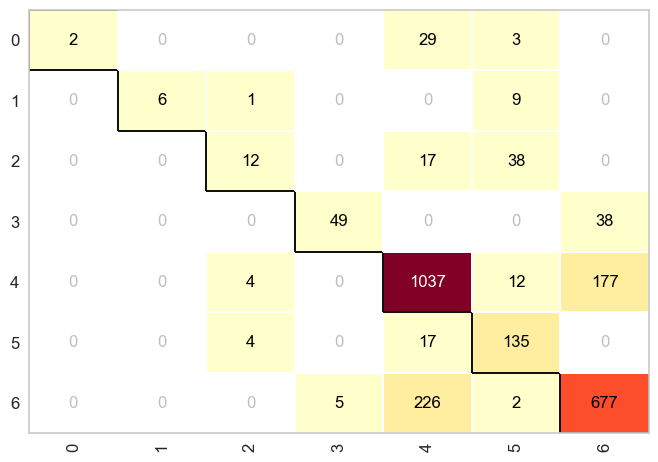

In [10]:
cm = ConfusionMatrix(sv_classifier, force_model=True)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

Exiba o reporte de classificação.

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.06      0.11        34
           1       1.00      0.38      0.55        16
           2       0.57      0.18      0.27        67
           3       0.91      0.56      0.70        87
           4       0.78      0.84      0.81      1230
           5       0.68      0.87      0.76       156
           6       0.76      0.74      0.75       910

    accuracy                           0.77      2500
   macro avg       0.81      0.52      0.56      2500
weighted avg       0.77      0.77      0.76      2500

